# 03 Q3 Design Justification

Main-body figure notebook for temporal decomposition and routing organization.

In [16]:
import importlib
import matplotlib.pyplot as plt
import real_final_viz_helpers as viz
importlib.reload(viz)

annotate_demo  = viz.annotate_demo
apply_style    = viz.apply_style
bar_line_panel = viz.bar_line_panel
load_csv       = viz.load_csv
preview_frame  = viz.preview_frame
PALETTE        = viz.PALETTE
DATASET_LABELS = viz.DATASET_LABELS
panel_label    = viz.panel_label


In [17]:
q3_temporal = load_csv('q3_temporal_decomp.csv')
q3_org = load_csv('q3_routing_org.csv')
preview_frame(q3_temporal)

rows=9 cols=10
['dataset', 'variant_label', 'variant_group', 'variant_order', 'test_ndcg20', 'test_hit10', 'base_rank', 'seed_id', 'data_status', 'data_note']


,dataset,variant_label,variant_group,variant_order,test_ndcg20,test_hit10,base_rank,seed_id,data_status,data_note
0,beauty,Single-view,temporal_decomp,1,0.080,0.13200,1,1,demo_dummy,Preview-only synthetic values for notebook des...
1,beauty,Best 2-view,temporal_decomp,2,0.086,0.14190,1,1,demo_dummy,Preview-only synthetic values for notebook des...
2,beauty,Final 3-stage,temporal_decomp,3,0.091,0.15015,1,1,demo_dummy,Preview-only synthetic values for notebook des...
3,foursquare,Single-view,temporal_decomp,1,0.198,0.32670,1,1,demo_dummy,Preview-only synthetic values for notebook des...
4,foursquare,Best 2-view,temporal_decomp,2,0.206,0.33990,1,1,demo_dummy,Preview-only synthetic values for notebook des...


In [18]:
apply_style()

# Q3(a): temporal decomposition variants.
temporal_plot = (
    q3_temporal
    .groupby(['variant_label', 'variant_order'], as_index=False)[['test_ndcg20', 'test_hit10']]
    .mean()
    .sort_values('variant_order', kind='stable')
)

# Q3(b): routing organization variants.
org_plot = (
    q3_org
    .groupby(['variant_label', 'variant_order'], as_index=False)[['test_ndcg20', 'test_hit10']]
    .mean()
    .sort_values('variant_order', kind='stable')
)


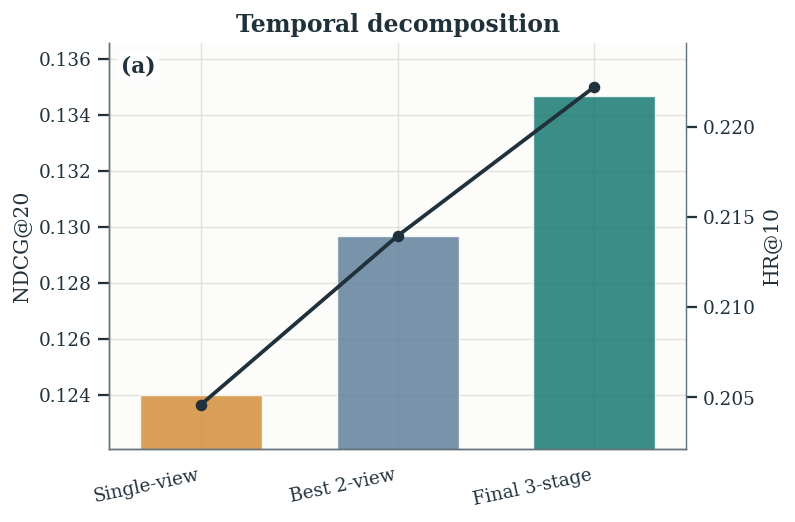

In [19]:
# (a) Temporal decomposition matters.
fig, ax = plt.subplots(1, 1, figsize=(6.0, 3.9), constrained_layout=True)

bar_line_panel(
    temporal_plot,
    category_col='variant_label',
    ndcg_col='test_ndcg20',
    hr_col='test_hit10',
    order=temporal_plot['variant_label'].tolist(),
    ax=ax,
    title='Temporal decomposition',
    xrotation=12,
)
panel_label(ax, 'a')
plt.show()


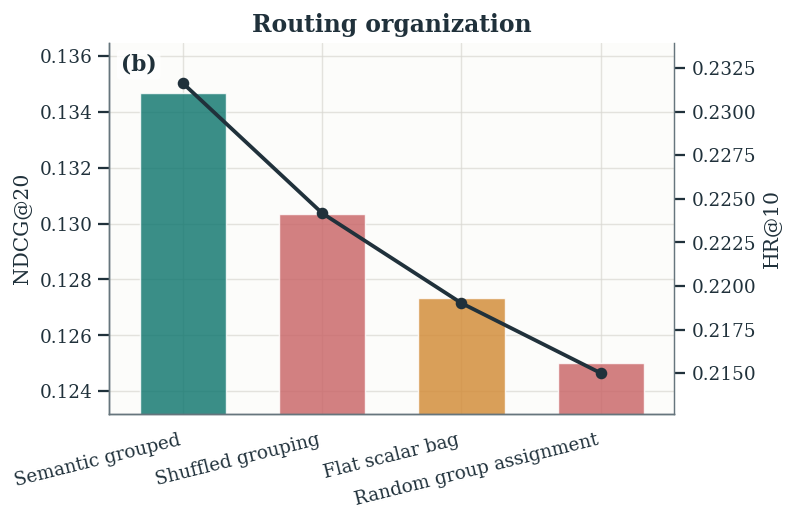

In [20]:
# (b) Hierarchical sparse routing matters.
fig, ax = plt.subplots(1, 1, figsize=(6.0, 3.9), constrained_layout=True)

bar_line_panel(
    org_plot,
    category_col='variant_label',
    ndcg_col='test_ndcg20',
    hr_col='test_hit10',
    order=org_plot['variant_label'].tolist(),
    ax=ax,
    title='Routing organization',
    xrotation=14,
)
panel_label(ax, 'b')
plt.show()
